# M4 real-data fit and IOS study

This is the current research notebook. Reusable mathematics, optimization,
analysis, and figures live in `student_kramers/*.py`; each code cell below is
short and only loads results or calls a reusable function.

## 0. Scope and reproducibility

The current formal fit is `m4_real_data_cholesky`. The shared sampled pilot is
`ios_pilot_cholesky`, and all observed exact IOS checkpoints are in
`ios_observed`.

Historical recovery, discrimination, and nested-bootstrap results used an
earlier M4 optimizer. They remain in the workflow record, but are not used as
formal evidence in this notebook.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display

PROJECT_DIR = Path.cwd().resolve()
if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from student_kramers import config
from student_kramers.data_loading import load_model_fits, load_real_data, load_result
from student_kramers.figures import (
    plot_ios_numerical_diagnostics, plot_ios_overview, plot_ios_phase_space,
    plot_modelwise_ios_bootstrap, plot_real_data_mechanisms,
    plot_real_data_state_space,
)

/Users/sal/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
FIT_RUN = "m4_real_data_cholesky"
PILOT_RUN = "ios_pilot_cholesky"
IOS_RUN = "ios_observed"
BOOTSTRAP_RUN = "m4_modelwise_ios_bootstrap"
FIGURE_DIR = config.run_dir(IOS_RUN) / "figures"

_, age, x, data = load_real_data()
fits = load_model_fits(FIT_RUN, required=True, data=data)
print(f"{len(data) - 1} observed transitions; results: {config.run_dir(IOS_RUN)}")

2499 observed transitions; results: /Users/sal/Desktop/Statistic Project/项目/results/runs/ios_observed


## 1. Current M4 definition and formal real-data fit

M4 changes only the squared diffusion:

$$
q_{M4}(x,v)=\alpha v^2+\beta v+\gamma+\delta x^2+\epsilon xv+\zeta x.
$$

For $y=(x,v,1)^\top$, the optimizer represents:

$$
q_{M4}(x,v)-q_{\mathrm{floor}}=y^\top LL^\top y,
$$

so every M4 trial point is globally valid. The tail condition is encoded as

$$
\alpha=2\eta\operatorname{logistic}(\rho),
$$

which guarantees $0<\alpha<2\eta$ throughout optimization.

In [3]:
fit_columns = [
    "model", "n_free", "nll", "aic", "bic",
    "q_min_global", "q_min_observed", "q_min_protected", "convergence",
]
display(fits[fit_columns].round(6))

,model,n_free,nll,aic,bic,q_min_global,q_min_observed,q_min_protected,convergence
0,M2,6,8524.347708,17060.695416,17095.637291,4176.668090,4176.668090,4176.668090,0
1,M3,8,8524.058929,17064.117858,17110.707026,4167.946212,4167.946212,4167.946212,0
2,M4,11,8499.311650,17020.623299,17084.683404,0.000276,3867.032067,3695.788780,0


/Users/sal/Desktop/Statistic Project/项目/student_kramers/figures.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


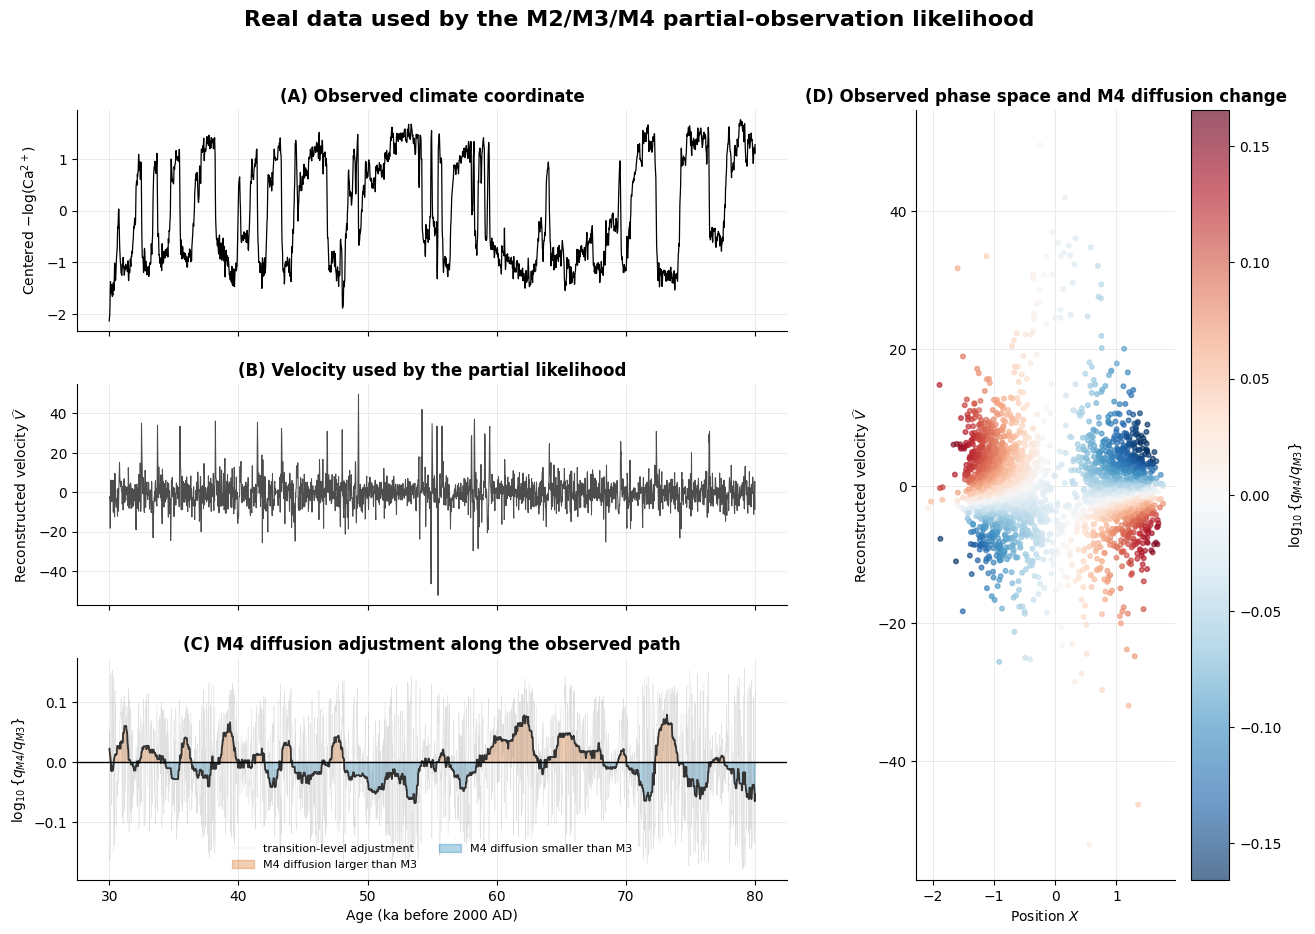

In [4]:
plot_real_data_state_space(
    age, x, data, fits, FIGURE_DIR / "current_real_data_state_space.png"
);

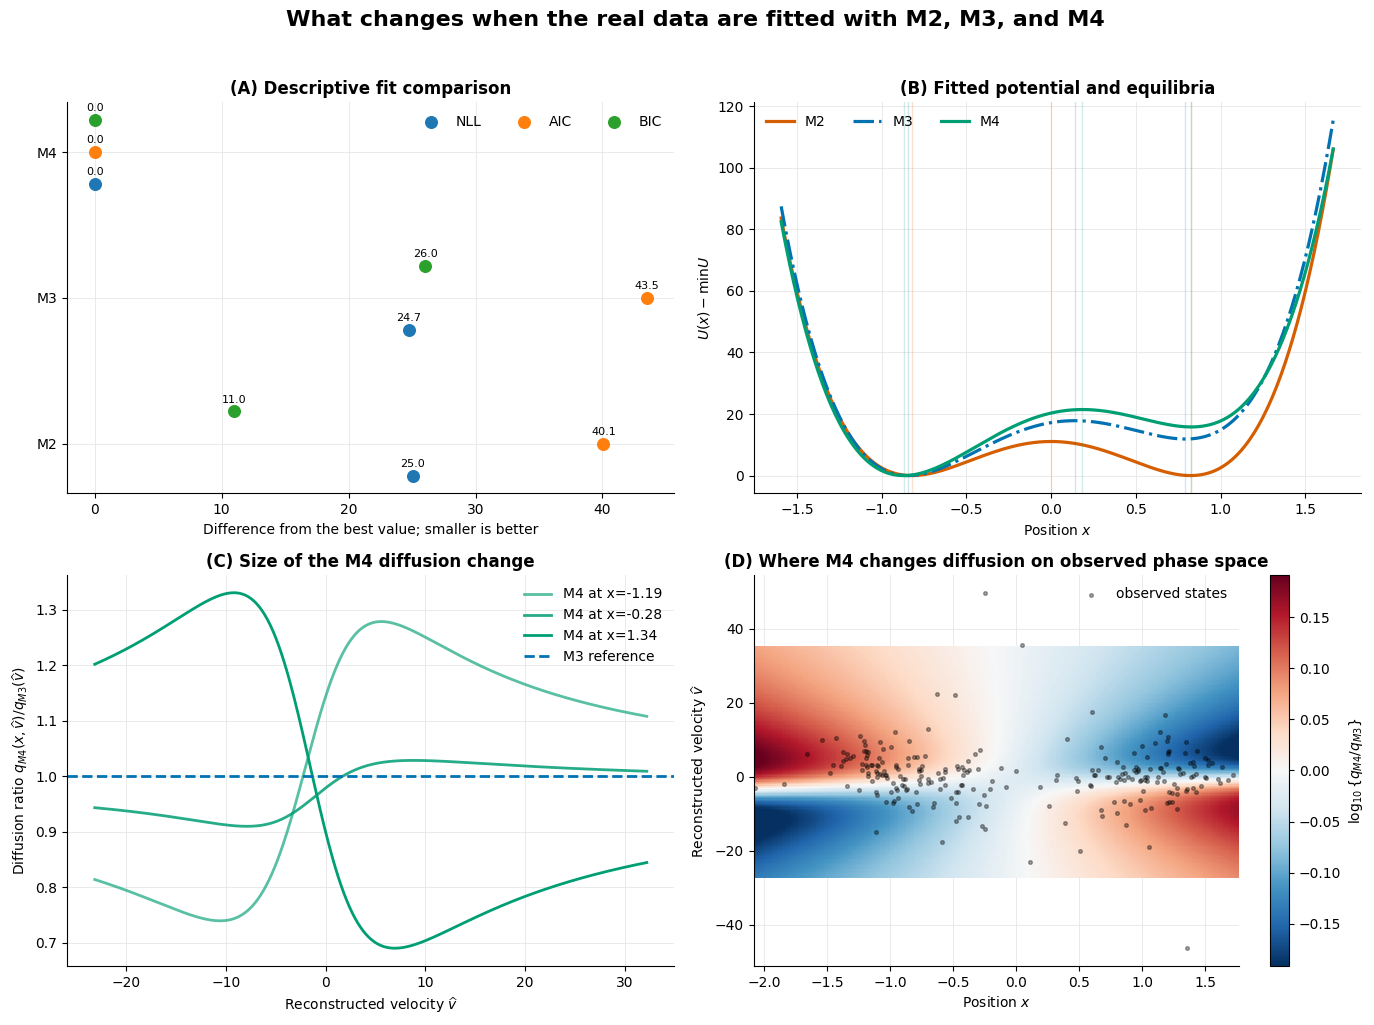

In [5]:
plot_real_data_mechanisms(
    fits, data, FIGURE_DIR / "current_real_data_mechanisms.png"
);

## 2. Stage A: IOS code and optimizer audit

The IOS implementation accepts a row only when the leave-one-out fit is
finite, constraint-valid, optimizer-valid, and no worse than its warm start
beyond numerical tolerance. Invalid checkpoint rows are retried.

The M4 full fit was also compared with the exact M3 boundary and several
globally valid interior starts.

In [6]:
stability = load_result(
    "m4_optimization_stability", run_name="ios_cholesky_audit_v2"
)
display(stability[[
    "start_kind", "nll", "convergence", "q_min_global",
    "q_min_observed", "distance_to_final_m4", "time_sec",
]].round(6))

,start_kind,nll,convergence,q_min_global,q_min_observed,distance_to_final_m4,time_sec
0,M3 boundary,8524.058902,0,4169.210607,4169.210607,613.139604,1.055178
1,final M4 warm start,8499.311650,0,0.000276,3867.032067,0.000000,0.418103
2,global interior,8499.360074,0,3942.428660,3942.428660,33.783807,4.319924
3,global interior,8499.360079,0,3942.424958,3942.424958,33.742125,4.298550
4,global interior,8499.360075,0,3942.430523,3942.430523,33.797767,4.863897
5,global interior,8499.360074,0,3942.467712,3942.467712,33.804436,3.453484
6,global interior,8499.360075,0,3942.442761,3942.442761,33.850742,3.985135
7,global interior,8499.360074,0,3942.483292,3942.483292,33.841993,3.866019


## 3. Stage B: shared sampled IOS pilot

The same 48 diagnostically diverse transitions were used for M2, M3, and M4.
This pilot checks optimization and cost. Its sampled sums are **not** formal
$T_N$ statistics.

In [7]:
pilot_validation = load_result("ios_pilot_validation", run_name=PILOT_RUN)
pilot_summary = load_result("ios_pilot_comparison", run_name=PILOT_RUN)
display(pilot_validation)
display(pilot_summary[[
    "model", "n_valid", "sampled_ios_sum", "median_nit",
    "max_nit", "median_seconds", "max_parameter_shift_relative",
]].round(4))

,model,n_expected,n_rows,n_valid,n_missing,n_invalid,unexpected_rows,complete_and_valid
0,M2,48,48,48,0,0,0,True
1,M3,48,48,48,0,0,0,True
2,M4,48,48,48,0,0,0,True


,model,n_valid,sampled_ios_sum,median_nit,max_nit,median_seconds,max_parameter_shift_relative
0,M2,48,5.2265,6.5,30,0.1185,0.1732
1,M3,48,6.2056,10.0,44,0.2135,0.4608
2,M4,48,10.1285,69.0,109,2.0855,0.4885


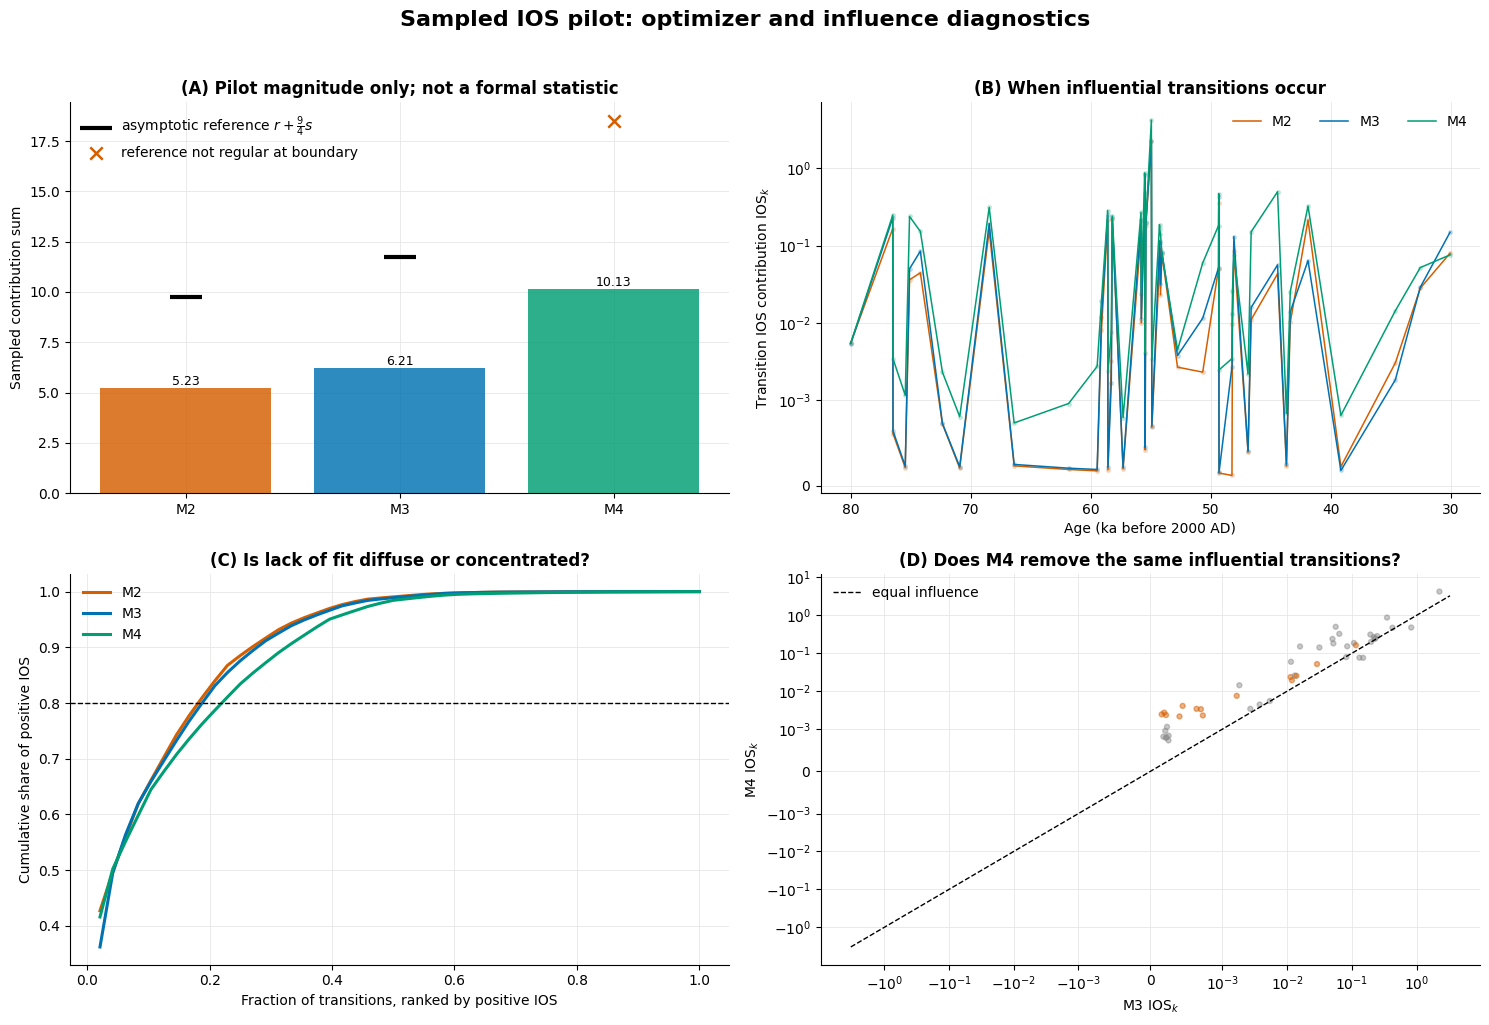

In [8]:
pilot_transitions = load_result("ios_pilot_transitions", run_name=PILOT_RUN)
plot_ios_overview(
    pilot_summary, pilot_transitions,
    FIGURE_DIR / "shared_sampled_ios_pilot.png",
);

## 4. Stage C: observed exact IOS

For transition $k$:

$$
\operatorname{IOS}_k
=\ell_k(\widehat\theta_{-k})-\ell_k(\widehat\theta),
\qquad
T_N=\sum_{k=1}^{2499}\operatorname{IOS}_k.
$$

Only a complete, valid 2499-transition table is labelled formal observed
exact IOS. A formal finite-sample goodness-of-fit conclusion still requires a
separate model-wise IOS bootstrap.

In [9]:
ios_validation = load_result("ios_validation", run_name=IOS_RUN)
ios_summary = load_result("ios_comparison", run_name=IOS_RUN)
display(ios_validation)
display(ios_summary[[
    "model", "T_N", "asymptotic_reference", "reference_applicable",
    "T_N_over_reference", "n_valid", "n_failed", "total_seconds",
]].round(4))

,model,n_expected,n_rows,n_valid,n_missing,n_invalid,unexpected_rows,complete_and_valid
0,M2,2499,2499,2499,0,0,0,True
1,M3,2499,2499,2499,0,0,0,True
2,M4,2499,2499,2499,0,0,0,True


,model,T_N,asymptotic_reference,reference_applicable,T_N_over_reference,n_valid,n_failed,total_seconds
0,M2,8.5893,9.75,True,0.8809,2499,0,123.1121
1,M3,11.5488,11.75,True,0.9829,2499,0,182.1718
2,M4,21.8765,18.50,False,NaN,2499,0,3793.8558


In [10]:
concentration = ios_summary[[
    "model", "top_1_positive_share", "top_10_positive_share",
    "fraction_transitions_for_80pct_positive",
    "median_ios_contribution", "max_ios_contribution",
]]
display(concentration.round(4))

,model,top_1_positive_share,top_10_positive_share,fraction_transitions_for_80pct_positive,median_ios_contribution,max_ios_contribution
0,M2,0.2600,0.5109,0.0240,0.0002,2.2334
1,M3,0.1947,0.4464,0.0340,0.0002,2.2483
2,M4,0.1926,0.3643,0.0864,0.0012,4.2143


## 5. Stage D: where sensitivity occurs and whether models agree

These tables separate three questions:

- Are the largest influential transitions shared across models?
- Does M4 reorder the many ordinary transitions?
- Are sign-switch transitions unusually influential?

In [11]:
pairwise = load_result("ios_pairwise_comparison", run_name=IOS_RUN)
regime = load_result("ios_regime_summary", run_name=IOS_RUN)
display(pairwise.round(4))
display(regime.round(4))

,left_model,right_model,n_transitions,pearson_correlation,spearman_correlation,right_minus_left_sum,right_greater_fraction,top_20_overlap
0,M2,M3,2499,0.9745,0.8992,2.9595,0.9036,17
1,M2,M4,2499,0.9854,0.2763,13.2872,0.9968,14
2,M3,M4,2499,0.9575,0.3854,10.3277,0.9808,16


,model,regime_switch,n_transitions,ios_sum,mean_ios,median_ios,max_ios
0,M2,False,2450,8.0960,0.0033,0.0002,2.2334
1,M2,True,49,0.4932,0.0101,0.0003,0.0915
2,M3,False,2450,10.8525,0.0044,0.0002,2.2483
3,M3,True,49,0.6962,0.0142,0.0003,0.1266
4,M4,False,2450,20.8170,0.0085,0.0012,4.2143
5,M4,True,49,1.0595,0.0216,0.0031,0.1629


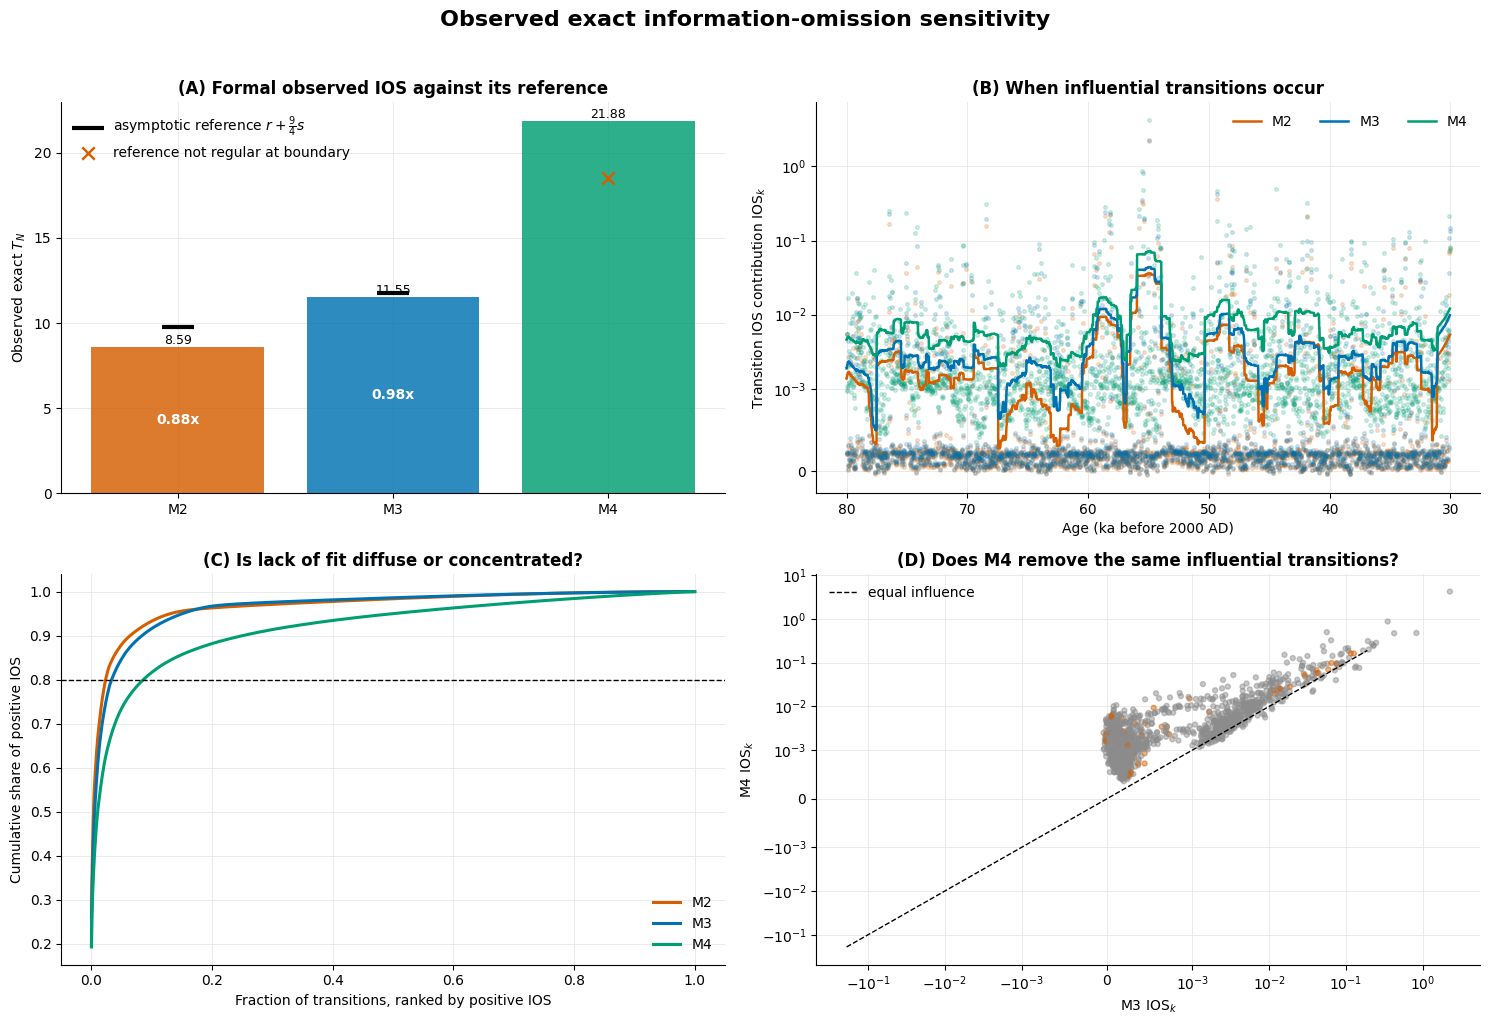

In [12]:
ios_transitions = load_result("ios_transitions", run_name=IOS_RUN)
plot_ios_overview(
    ios_summary, ios_transitions,
    FIGURE_DIR / "observed_exact_ios_overview.png",
);

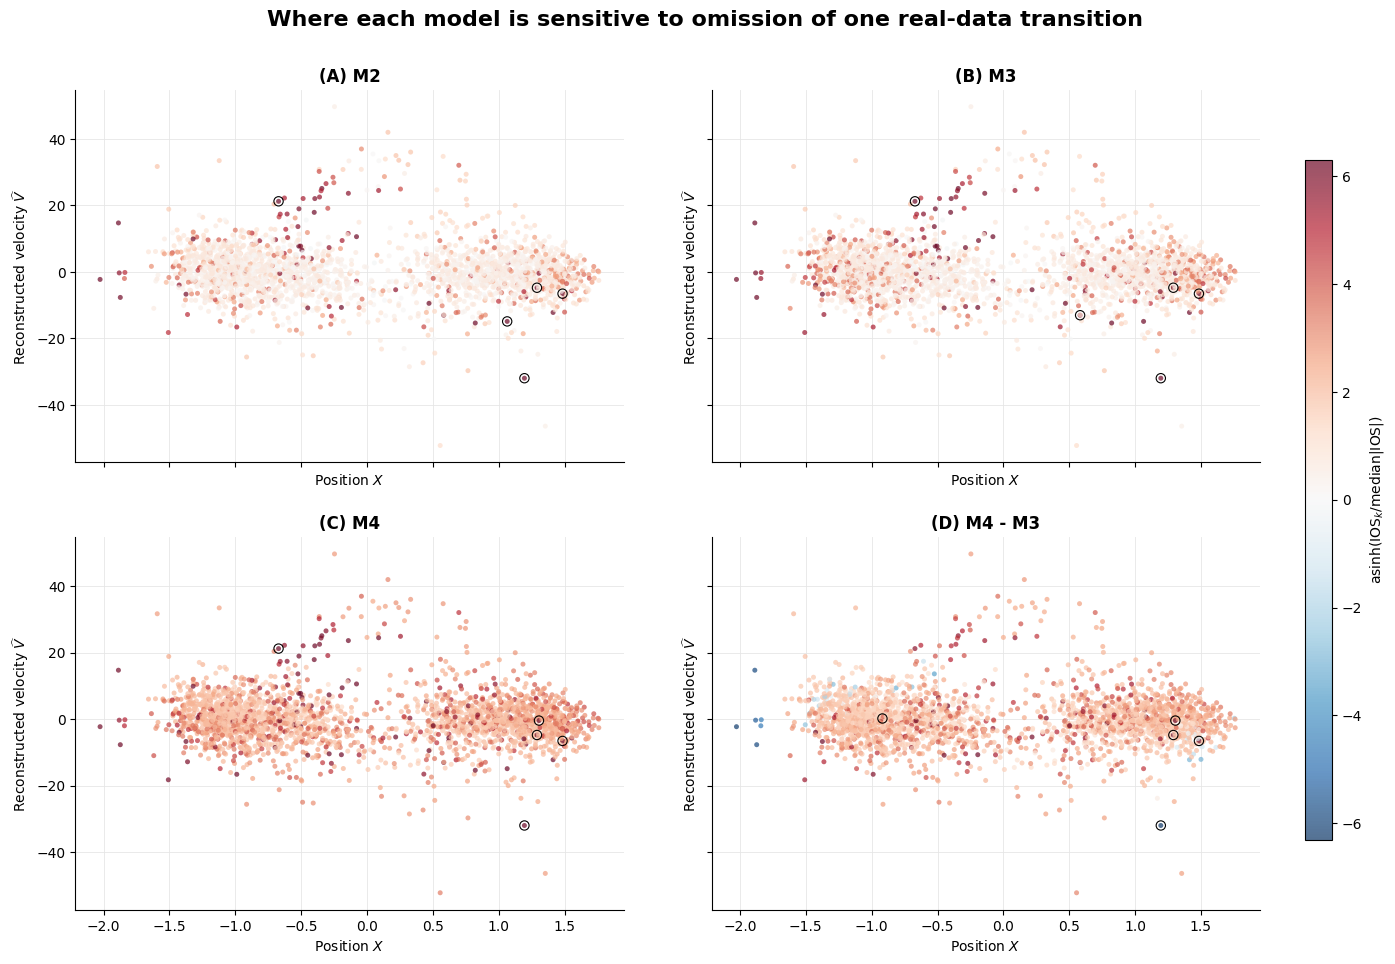

In [13]:
plot_ios_phase_space(
    ios_transitions,
    FIGURE_DIR / "observed_exact_ios_phase_space.png",
);

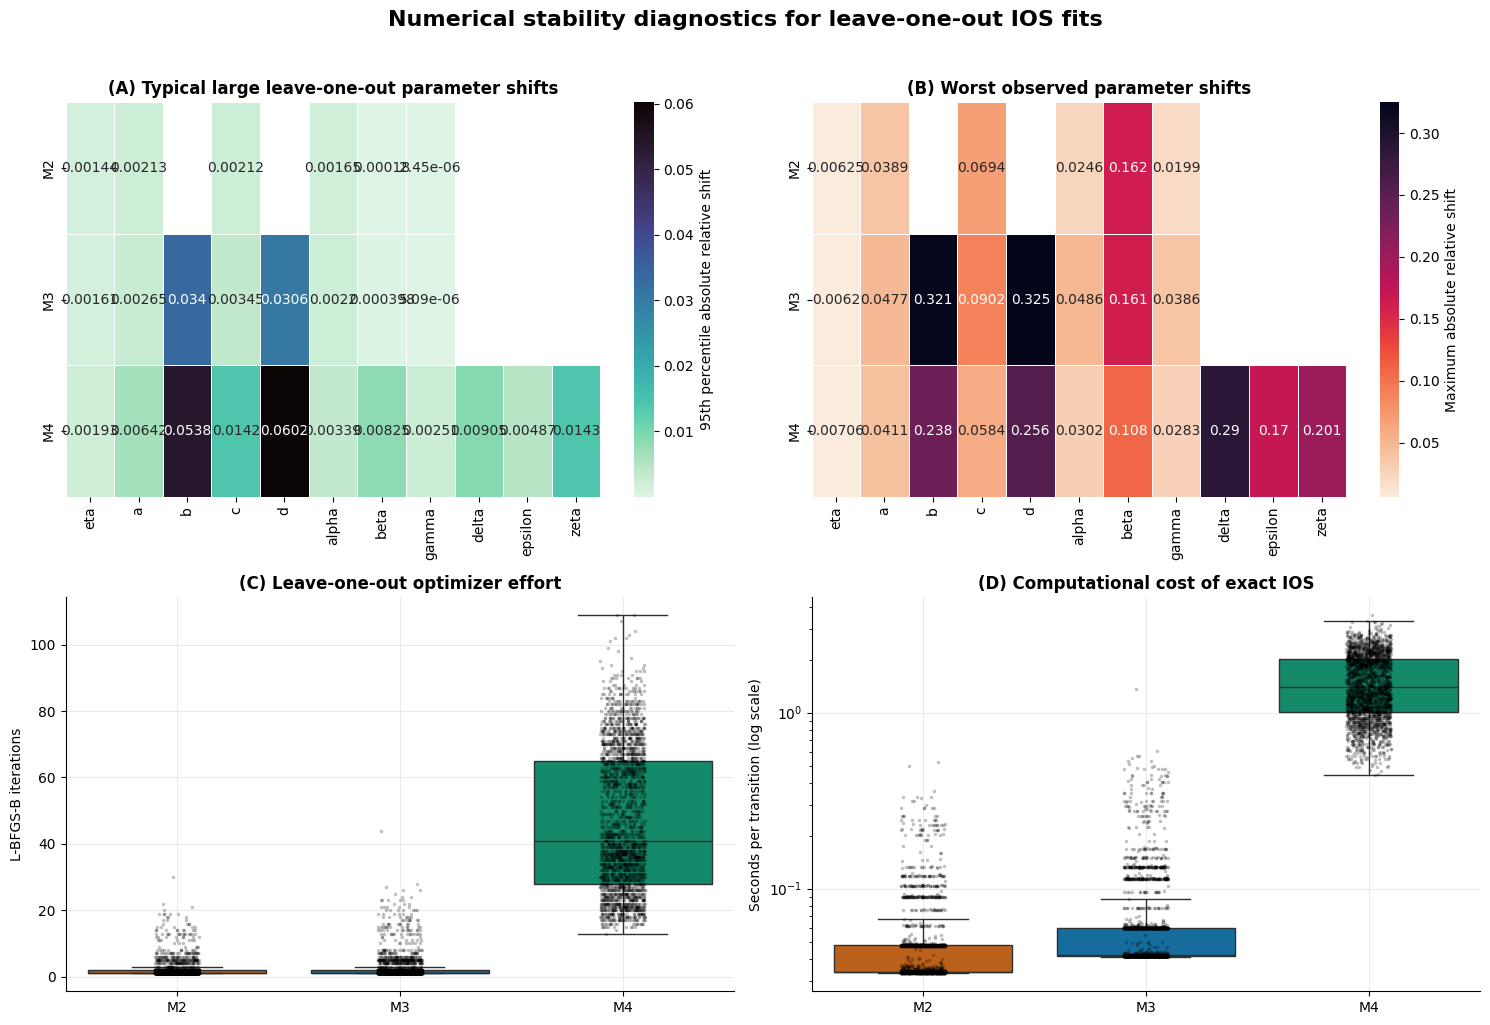

In [14]:
parameter_shifts = load_result("ios_parameter_shifts", run_name=IOS_RUN)
plot_ios_numerical_diagnostics(
    parameter_shifts, ios_transitions,
    FIGURE_DIR / "observed_exact_ios_numerical_diagnostics.png",
);

In [15]:
top_rows = []
for model in ("M2", "M3", "M4"):
    column = f"{model.lower()}_ios_contribution"
    top = ios_transitions.nlargest(5, column)[[
        "k", "age_ka", "X_old", "Vhat_old", "regime_switch", column,
    ]].copy()
    top.insert(0, "model", model)
    top_rows.append(top.rename(columns={column: "ios_contribution"}))
display(pd.concat(top_rows, ignore_index=True).round(4))

,model,k,age_ka,X_old,Vhat_old,regime_switch,ios_contribution
0,M2,1253,54.94,1.4848,-6.5468,False,2.2334
1,M2,1534,49.32,-0.6712,21.2362,False,0.3608
2,M2,1225,55.50,1.2907,-4.7610,False,0.3312
3,M2,1226,55.48,1.1955,-31.9821,False,0.3108
4,M2,1090,58.20,1.0646,-14.8922,False,0.2209
5,M3,1253,54.94,1.4848,-6.5468,False,2.2483
6,M3,1226,55.48,1.1955,-31.9821,False,0.8249
7,M3,1534,49.32,-0.6712,21.2362,False,0.4238
8,M3,1225,55.50,1.2907,-4.7610,False,0.3488
9,M3,1071,58.58,0.5827,-13.0318,False,0.2463


## 6. M4 finite-sample IOS calibration

The strict model-wise bootstrap repeats the full workflow:

$$
\text{simulate from fitted M4}
\longrightarrow \text{refit M4}
\longrightarrow \text{recompute exact }T_N^*.
$$

All 200 replications contain 2499 valid leave-one-out transitions.


In [16]:
bootstrap = load_result(
    "modelwise_ios_bootstrap", "M4", run_name=BOOTSTRAP_RUN,
)
bootstrap_summary = load_result(
    "modelwise_ios_bootstrap_summary", "M4", run_name=BOOTSTRAP_RUN,
)
bootstrap_cumulative = load_result(
    "modelwise_ios_bootstrap_cumulative", "M4", run_name=BOOTSTRAP_RUN,
)

display(bootstrap_summary[[
    "model", "observed_T_N", "n_success", "success_rate",
    "q025", "q50", "q975", "p_upper", "p_lower",
]])


,model,observed_T_N,n_success,success_rate,q025,q50,q975,p_upper,p_lower
0,M4,21.876493,200,1.0,21.089303,39.828553,154.800727,0.965174,0.039801


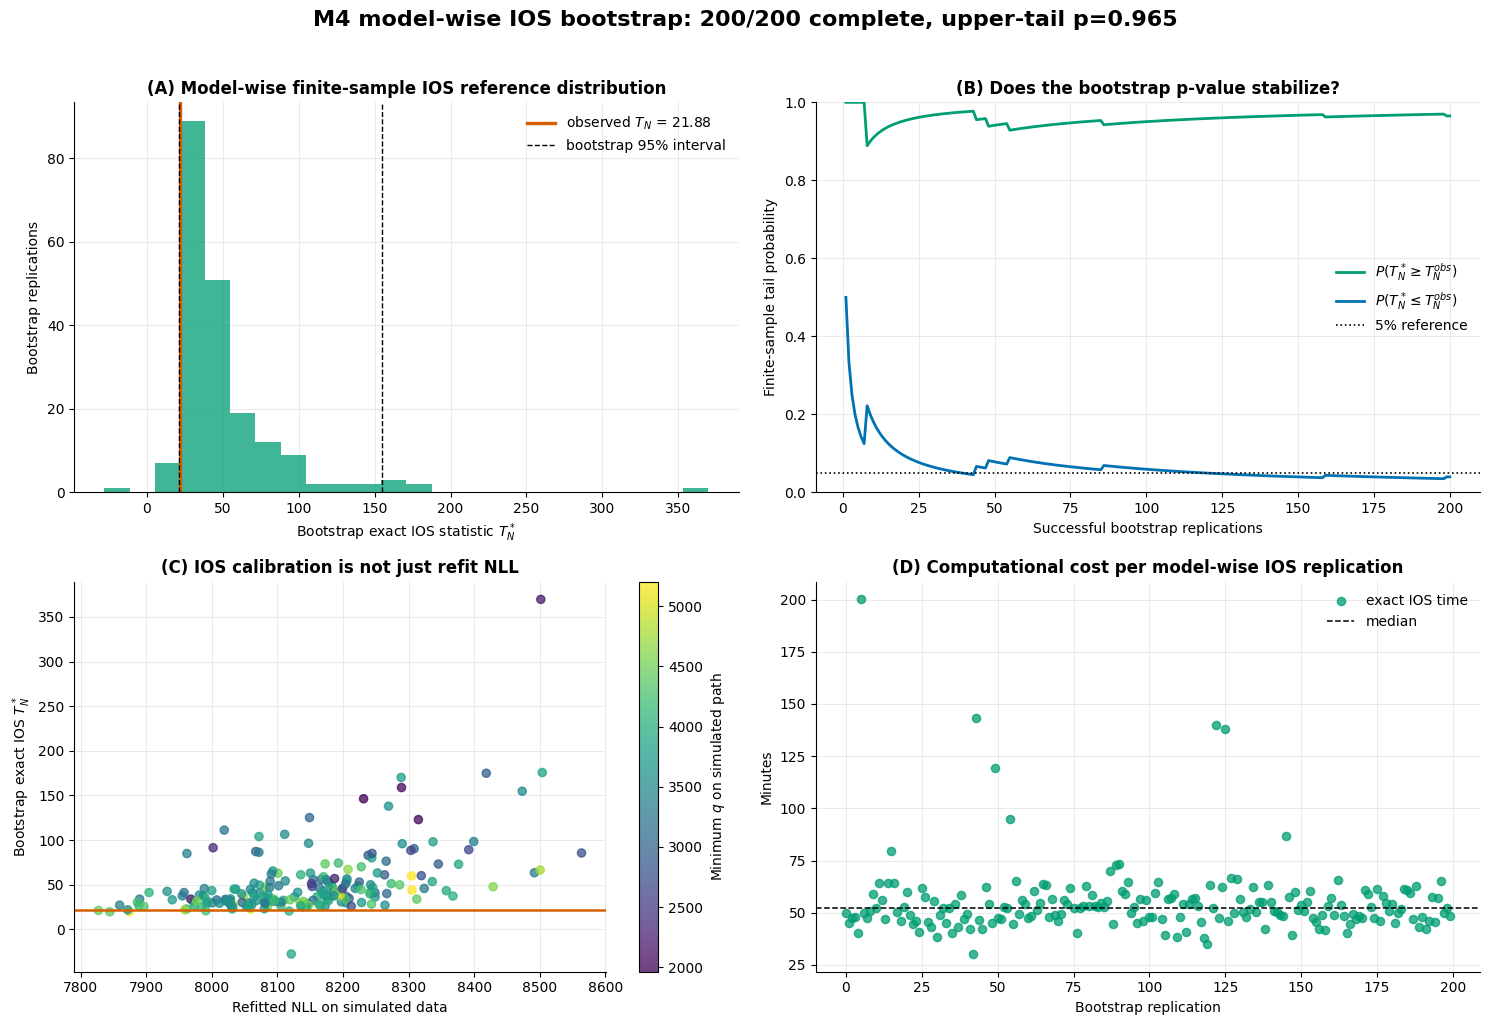

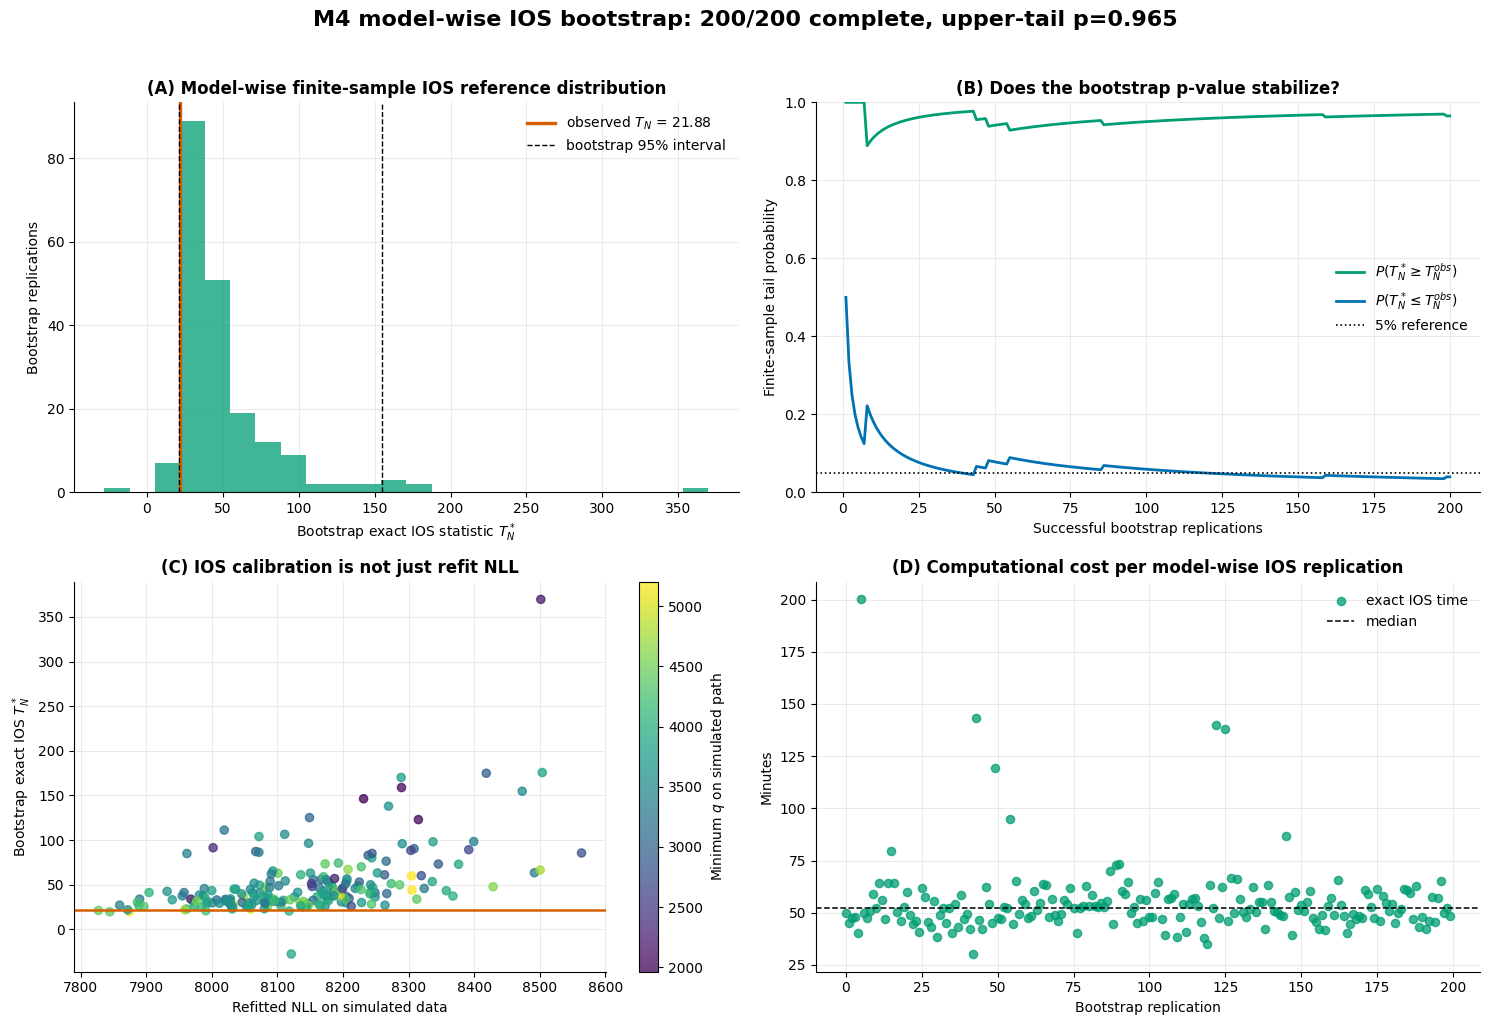

In [17]:
plot_modelwise_ios_bootstrap(
    bootstrap_summary,
    bootstrap_cumulative,
    bootstrap,
    config.run_dir(BOOTSTRAP_RUN) / "figures" / "m4_modelwise_ios_bootstrap.png",
)


### Finite-sample interpretation

- The observed statistic is $T_N^{obs}=21.876$.
- The bootstrap median is $39.829$ and the 95% interval is
  $[21.089,154.801]$.
- The upper-tail probability is $0.965$. The observed IOS is not unusually
  large under fitted M4, so this IOS goodness-of-fit check does not reject M4.
- The lower-tail probability is $0.040$. The observed statistic lies near the
  lower edge of the finite-sample reference distribution. This is not evidence
  of poor fit in the usual upper-tail IOS test, but it is a diagnostic signal:
  the observed path is less leave-one-out sensitive than most fitted-M4
  simulations.
- The distribution is strongly right-skewed, so the median and empirical
  quantiles are more informative than the mean alone.


## 7. Current interpretation

- M2, M3, and M4 observed exact IOS calculations all contain 2499/2499 valid
  transitions.
- M4 has $T_N=21.876$. The strict 200-replication model-wise bootstrap gives an
  upper-tail probability of $0.965$, so the IOS goodness-of-fit check does not
  find an unusually large lack-of-fit statistic.
- The observed M4 statistic is nevertheless near the lower edge of its
  bootstrap distribution: lower-tail probability $0.040$. This should be
  reported as a calibration diagnostic, not converted into a claim that M4 is
  proven correct.
- M2 and M3 rank influential transitions similarly. M4 shares the largest
  extremes, but substantially reorders ordinary transitions and spreads
  sensitivity over a larger fraction of the path.
- The most influential observed transition for every model occurs near
  54.94 ka.

The current evidence therefore says that M4 passes the planned upper-tail IOS
check on this dataset, while the low observed statistic and the heavy
right-tailed bootstrap distribution deserve further scientific interpretation.


## 8. Exact reproducibility commands

Observed exact IOS:

```bash
env VECLIB_MAXIMUM_THREADS=1 OPENBLAS_NUM_THREADS=1 \
    OMP_NUM_THREADS=1 MKL_NUM_THREADS=1 \
    python3 -m student_kramers.run_bootstrap \
    --mode ios --fit-run m4_real_data_cholesky \
    --run-name ios_observed --model M4 --n-starts 1 --maxiter 120

python3 -m student_kramers.run_ios_analysis \
    --fit-run m4_real_data_cholesky --run-name ios_observed
```

Strict M4 model-wise IOS bootstrap and analysis:

```bash
env VECLIB_MAXIMUM_THREADS=1 OPENBLAS_NUM_THREADS=1 \
    OMP_NUM_THREADS=1 MKL_NUM_THREADS=1 \
    python3 -m student_kramers.run_modelwise_ios_bootstrap \
    --fit-run m4_real_data_cholesky \
    --run-name m4_modelwise_ios_bootstrap \
    --model M4 --n-boot 200 --n-workers 6 --retry-failed

python3 -m student_kramers.run_modelwise_ios_analysis \
    --run-name m4_modelwise_ios_bootstrap \
    --observed-run ios_observed --model M4
```

Every transition and replication is checkpointed. With unchanged code and
settings, rerunning resumes instead of repeating completed work.
